In [10]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import metrics
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# maximize display of dataframe columns
pd.set_option('display.max_columns', None)

df = pd.read_csv('train.csv')

In [11]:
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,wtd_std_atomic_mass,mean_fie,wtd_mean_fie,gmean_fie,wtd_gmean_fie,entropy_fie,wtd_entropy_fie,range_fie,wtd_range_fie,std_fie,wtd_std_fie,mean_atomic_radius,wtd_mean_atomic_radius,gmean_atomic_radius,wtd_gmean_atomic_radius,entropy_atomic_radius,wtd_entropy_atomic_radius,range_atomic_radius,wtd_range_atomic_radius,std_atomic_radius,wtd_std_atomic_radius,mean_Density,wtd_mean_Density,gmean_Density,wtd_gmean_Density,entropy_Density,wtd_entropy_Density,range_Density,wtd_range_Density,std_Density,wtd_std_Density,mean_ElectronAffinity,wtd_mean_ElectronAffinity,gmean_ElectronAffinity,wtd_gmean_ElectronAffinity,entropy_ElectronAffinity,wtd_entropy_ElectronAffinity,range_ElectronAffinity,wtd_range_ElectronAffinity,std_ElectronAffinity,wtd_std_ElectronAffinity,mean_FusionHeat,wtd_mean_FusionHeat,gmean_FusionHeat,wtd_gmean_FusionHeat,entropy_FusionHeat,wtd_entropy_FusionHeat,range_FusionHeat,wtd_range_FusionHeat,std_FusionHeat,wtd_std_FusionHeat,mean_ThermalConductivity,wtd_mean_ThermalConductivity,gmean_ThermalConductivity,wtd_gmean_ThermalConductivity,entropy_ThermalConductivity,wtd_entropy_ThermalConductivity,range_ThermalConductivity,wtd_range_ThermalConductivity,std_ThermalConductivity,wtd_std_ThermalConductivity,mean_Valence,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,53.622535,775.425,1010.268571,718.152900,938.016780,1.305967,0.791488,810.6,735.985714,323.811808,355.562967,160.25,105.514286,136.126003,84.528423,1.259244,1.207040,205,42.914286,75.237540,69.235569,4654.35725,2961.502286,724.953211,53.543811,1.033129,0.814598,8958.571,1579.583429,3306.162897,3572.596624,81.8375,111.727143,60.123179,99.414682,1.159687,0.787382,127.05,80.987143,51.433712,42.558396,6.9055,3.846857,3.479475,1.040986,1.088575,0.994998,12.878,1.744571,4.599064,4.666920,107.756645,61.015189,7.062488,0.621979,0.308148,0.262848,399.97342,57.127669,168.854244,138.517163,2.25,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,53.979870,766.440,1010.612857,720.605511,938.745413,1.544145,0.807078,810.6,743.164286,290.183029,354.963511,161.20,104.971429,141.465215,84.370167,1.508328,1.204115,205,50.571429,67.321319,68.008817,5821.48580,3021.016571,1237.095080,54.095718,1.314442,0.914802,10488.571,1667.383429,3767.403176,3632.649185,90.8900,112.316429,69.833315,101.166398,1.427997,0.838666,127.05,81.207857,49.438167,41.667621,7.7844,3.796857,4.403790,1.035251,1.374977,1.073094,12.878,1.595714,4.473363,4.603000,172.205316,61.372331,16.064228,0.619735,0.847404,0.567706,429.97342,51.413383,198.554600,139.630922,2.00,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,53.656268,775.425,1010.820000,718.152900,939.009036,1.305967,0.773620,810.6,743.164286,323.811808,354.804183,160.25,104.685714,136.126003,84.214573,1.259244,1.132547,205,49.314286,75.237540,67.797712,4654.35725,2999.159429,724.953211,53.974022,1.033129,0.760305,8958.571,1667.383429,3306.162897,3592.019281,81.8375,112.213571,60.123179,101.082152,1.159687,0.786007,127.05,81.207857,51.433712,41.639878,6.9055,3.822571,3.479475,1.037439,1.088575,0.927479,12.878,1.757143,4.599064,4.649635,107.756645,60.943760,7.062488,0.619095,0.308148,0.250477,399.97342,57.127669,168.854244,138.540613,2.25,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,53.639405,775.425,1

## Helper functions

In [12]:
# Helper functions for plotting things
def plot_pred_vs_true(y_true, y_pred, title="Predicted vs True"):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, '--', linewidth=1.0, color='grey')
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_residuals(y_true, y_pred, title="Residuals"):
    resid = y_true - y_pred
    plt.figure(figsize=(10,4))

    # left: histogram
    plt.subplot(1,2,1)
    plt.hist(resid, bins=20, edgecolor='black')
    plt.title("Residual Histogram")
    plt.xlabel("Residual")
    plt.ylabel("Count")

    # right: residual scatter
    plt.subplot(1,2,2)
    plt.scatter(y_pred, resid, alpha=0.6)
    plt.axhline(0, color='grey', linestyle='--')
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(title)

    plt.tight_layout()
    plt.show()

def print_regression_metrics(y_true, y_pred, prefix=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{prefix}MAE:  {mae:.4f}")
    print(f"{prefix}RMSE: {rmse:.4f}")
    print(f"{prefix}R²:   {r2:.4f}")

    return {"MAE": mae, "RMSE": rmse, "R2": r2}

In [13]:
# Separate features and target
X = df.drop('critical_temp', axis=1)
y = df['critical_temp']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Baseline: simple GradientBoostingRegressor

Baseline model performance on test set:
  MAE:  8.4995
  RMSE: 12.3327
  R²:   0.8679


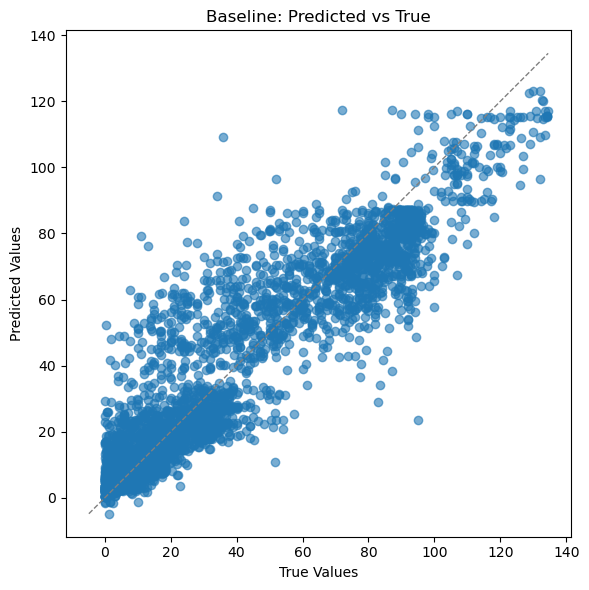

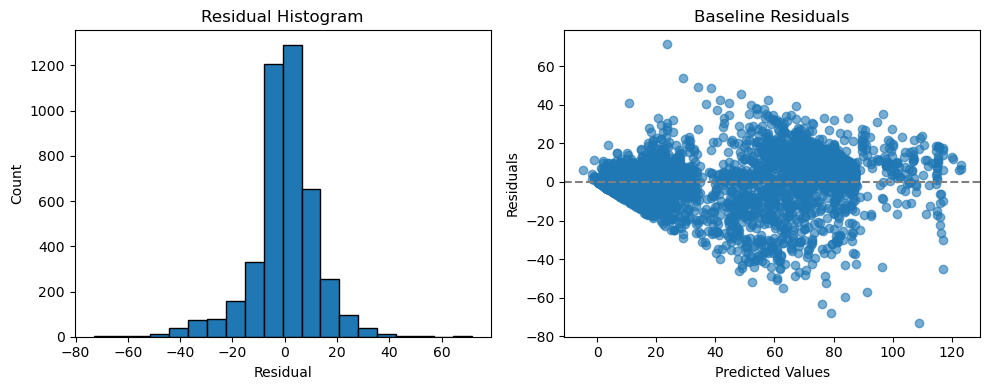

In [14]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("gbr", GradientBoostingRegressor(random_state=42))
])

pipeline.fit(X_train, y_train)

y_pred_test = pipeline.predict(X_test)

print("Baseline model performance on test set:")
baseline_metrics = print_regression_metrics(y_test, y_pred_test, prefix="  ")

plot_pred_vs_true(y_test, y_pred_test, "Baseline: Predicted vs True")
plot_residuals(y_test, y_pred_test, "Baseline Residuals")

## GridSearch for hyperparameter optimization

In [15]:
param_grid = {
    "gbr__n_estimators": [100, 300],
    "gbr__learning_rate": [0.01, 0.05, 0.1],
    "gbr__max_depth": [3, 5, 7],
    "gbr__subsample": [0.8, 1.0],
    "gbr__min_samples_split": [2, 5],
}

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("gbr", GradientBoostingRegressor(random_state=42))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

gs.fit(X_train, y_train)

print("Best parameters found:")
print(gs.best_params_)
print("Best CV score (neg RMSE):", gs.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END gbr__learning_rate=0.01, gbr__max_depth=3, gbr__min_samples_split=2, gbr__n_estimators=100, gbr__subsample=0.8; total time=  18.4s
[CV] END gbr__learning_rate=0.01, gbr__max_depth=3, gbr__min_samples_split=2, gbr__n_estimators=100, gbr__subsample=0.8; total time=  18.5s
[CV] END gbr__learning_rate=0.01, gbr__max_depth=3, gbr__min_samples_split=2, gbr__n_estimators=100, gbr__subsample=0.8; total time=  18.6s
[CV] END gbr__learning_rate=0.01, gbr__max_depth=3, gbr__min_samples_split=2, gbr__n_estimators=100, gbr__subsample=0.8; total time=  18.5s
[CV] END gbr__learning_rate=0.01, gbr__max_depth=3, gbr__min_samples_split=2, gbr__n_estimators=100, gbr__subsample=0.8; total time=  18.7s
[CV] END gbr__learning_rate=0.01, gbr__max_depth=3, gbr__min_samples_split=2, gbr__n_estimators=100, gbr__subsample=1.0; total time=  22.3s
[CV] END gbr__learning_rate=0.01, gbr__max_depth=3, gbr__min_samples_split=2, gbr__n_estimators=10

In [16]:
cv_results = pd.DataFrame(gs.cv_results_).sort_values("rank_test_score")
cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gbr__learning_rate,param_gbr__max_depth,param_gbr__min_samples_split,param_gbr__n_estimators,param_gbr__subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
67,168.530145,0.491917,0.026208,0.003186,0.10,7,2,300,1.0,"{'gbr__learning_rate': 0.1, 'gbr__max_depth': ...",-10.253762,-9.586670,-9.349474,-9.518519,-9.887611,-9.719207,0.318952,1,-4.767392,-4.915265,-4.964637,-4.818312,-4.744810,-4.842083,0.084830
71,152.930683,11.762072,0.020689,0.001579,0.10,7,5,300,1.0,"{'gbr__learning_rate': 0.1, 'gbr__max_depth': ...",-10.117892,-9.589972,-9.342727,-9.568696,-10.004926,-9.724843,0.290351,2,-4.778812,-4.924521,-4.985656,-4.880186,-4.797756,-4.873386,0.077369
66,137.190548,0.826542,0.030272,0.004724,0.10,7,2,300,0.8,"{'gbr__learning_rate': 0.1, 'gbr__max_depth': ...",-10.314798,-9.707144,-9.264354,-9.576216,-9.952461,-9.762995,0.354127,3,-4.822251,-5.222484,-5.194214,-4.917706,-5.083057,-5.047942,0.155558
70,138.756834,0.393861,0.029381,0.001307,0.10,7,5,300,0.8,"{'gbr__learning_rate': 0.1, 'gbr__max_depth': ...",-10.203345,-9.587081,-9.417798,-9.669831,-10.016519,-9.778915,0.288341,4,-4.843616,-5.257336,-5.252397,-4.908210,-5.067972,-5.065906,0.170710
42,141.169708,0.577764,0.032067,0.002329,0.05,7,2,300,0.8,"{'gbr__learning_rate': 0.05, 'gbr__max_depth':...",-10.388330,-9.640820,-9.295144,-9.687166,-9.949599,-9.792212,0.363637,5,-5.587965,-6.015764,-5.910828,-5.717337,-5.864335,-5.819246,0.150277
46,1427.405729,86.730606,0.033241,0.003468,0.05,7,5,300,0.8,"{'gbr__learning_rate': 0.05, 'gbr__max_depth':...",-10.344262,-9.718221,-9.345707,-9.625002,-9.993393,-9.805317,0.339757,6,-5.668576,-6.038842,-5.954063,-5.746871,-5.902017,-5.862074,0.135660
47,605.256255,484.589526,0.031748,0.003082,0.05,7,5,300,1.0,"{'gbr__learning_rate': 0.05, 'gbr__max_depth':...",-10.259052,-9.673381,-9.505006,-9.693608,-9.948755,-9.815961,0.263042,7,-5.763627,-5.835902,-5.900253,-5.821987,-5.734793,-5.811312,0.057893
43,486.293619,464.720567,0.030896,0.002847,0.05,7,2,300,1.0,"{'gbr__learning_rate': 0.05, 'gbr__max_depth':...",-10.243655,-9.672847,-9.526704,-9.663110,-9.993769,-9.820017,0.261523,8,-5.692247,-5.815367,-5.865742,-5.822339,-5.689261,-5.776991,0.072504
65,55.250957,0.422770,0.014650,0.002085,0.10,7,2,100,1.0,"{'gbr__learning_rate': 0.1, 'gbr__max_depth': ...",-10.460547,-9.901381,-9.573224,-9.847668,-10.124779,-9.981520,0.296996,9,-6.361247,-6.461399,-6.452240,-6.412019,-6.263428,-6.390067,0.072531
69,54.953867,0.170116,0.013616,0.002047,0.10,7,5,100,1.0,"{'gbr__learning_rate': 0.1, 'gbr__max_depth': ...",-10.329626,-9.875170,-9.643390,-9.868006,-10.274332,-9.998105,0.262324,10,-6.254834,-6.476069,-6.543117,-6.513272,-6.329721,-6.423403,0.111690


## Best Model

Test set performance for best model:
  MAE:  5.2787
  RMSE: 9.0640
  R²:   0.9286


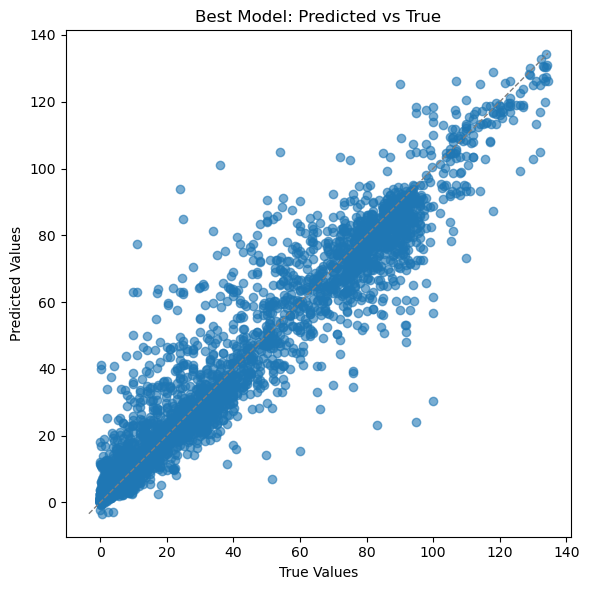

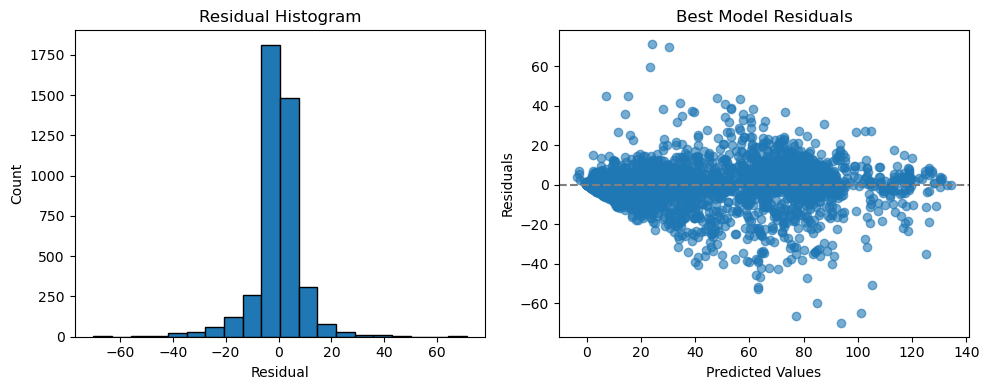

In [17]:
best_model = gs.best_estimator_
y_test_pred = best_model.predict(X_test)

print("Test set performance for best model:")
metrics = print_regression_metrics(y_test, y_test_pred, prefix="  ")

plot_pred_vs_true(y_test, y_test_pred, "Best Model: Predicted vs True")
plot_residuals(y_test, y_test_pred, "Best Model Residuals")

## Feature Importance

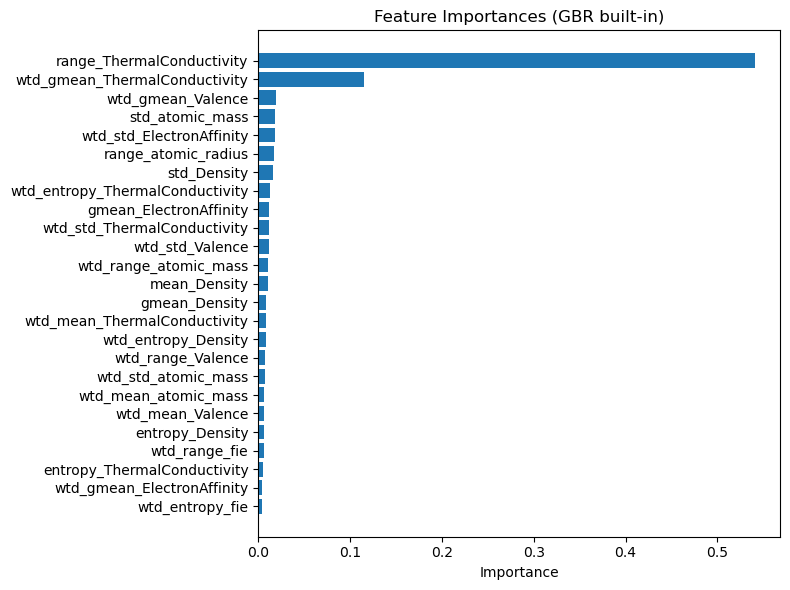

,feature,importance
67,range_ThermalConductivity,0.541125
64,wtd_gmean_ThermalConductivity,0.115372
74,wtd_gmean_Valence,0.019167
9,std_atomic_mass,0.018618
50,wtd_std_ElectronAffinity,0.018608
...,...,...
71,mean_Valence,0.000554
77,range_Valence,0.000446
37,range_Density,0.000320
57,range_FusionHeat,0.000295


In [18]:
importances = best_model.named_steps["gbr"].feature_importances_
feature_names = X.columns

sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8,6))
plt.barh(feature_names[sorted_idx][:25], importances[sorted_idx][:25])
plt.gca().invert_yaxis()
plt.title("Feature Importances (GBR built-in)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Full table
pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
    "importance", ascending=False
)

## Permutation Importance
### Evaluating Feature Influence by Randomly Shuffling

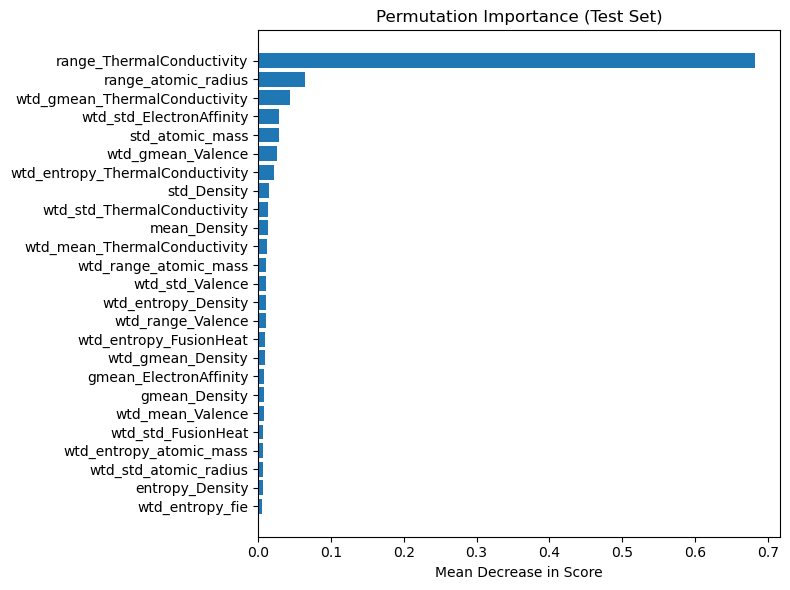

,feature,importance_mean,importance_std
67,range_ThermalConductivity,0.682468,0.014186
27,range_atomic_radius,0.064812,0.002603
64,wtd_gmean_ThermalConductivity,0.043680,0.003469
50,wtd_std_ElectronAffinity,0.028474,0.001775
9,std_atomic_mass,0.028403,0.001784
...,...,...,...
15,entropy_fie,0.000370,0.000139
11,mean_fie,0.000314,0.000165
37,range_Density,0.000194,0.000081
77,range_Valence,0.000028,0.000074


In [19]:
perm = permutation_importance(
    best_model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

# plot
plt.figure(figsize=(8,6))
plt.barh(perm_df["feature"].head(25), perm_df["importance_mean"].head(25))
plt.gca().invert_yaxis()
plt.title("Permutation Importance (Test Set)")
plt.xlabel("Mean Decrease in Score")
plt.tight_layout()
plt.show()

perm_df

## Choosing Features with importance_mean > 0.01

In [20]:
selected_features = perm_df[perm_df["importance_mean"] >= 0.01]["feature"].tolist()
print("Selected features:", selected_features)

X_reduced = X[selected_features]

# New train-test split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

print(f"Reduced feature count: {len(selected_features)} out of {X.shape[1]}")

Selected features: ['range_ThermalConductivity', 'range_atomic_radius', 'wtd_gmean_ThermalConductivity', 'wtd_std_ElectronAffinity', 'std_atomic_mass', 'wtd_gmean_Valence', 'wtd_entropy_ThermalConductivity', 'std_Density', 'wtd_std_ThermalConductivity', 'mean_Density', 'wtd_mean_ThermalConductivity', 'wtd_range_atomic_mass', 'wtd_std_Valence', 'wtd_entropy_Density', 'wtd_range_Valence']
Reduced feature count: 15 out of 81


## Baseline Model

Baseline reduced-feature model performance:
  MAE:  8.8672
  RMSE: 12.8294
  R²:   0.8570


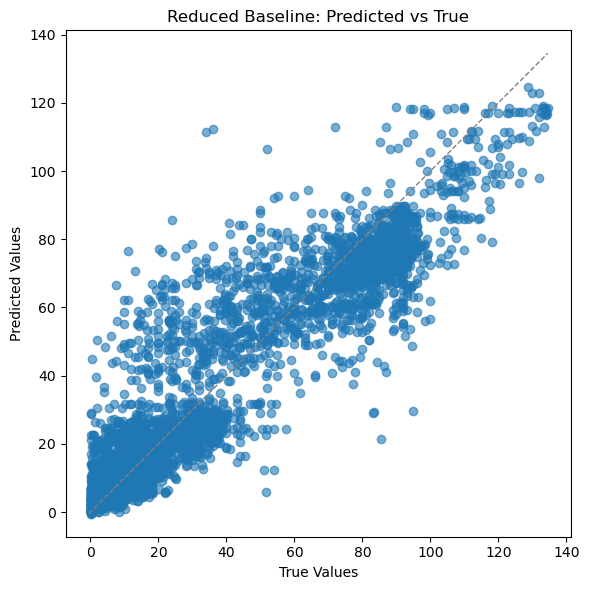

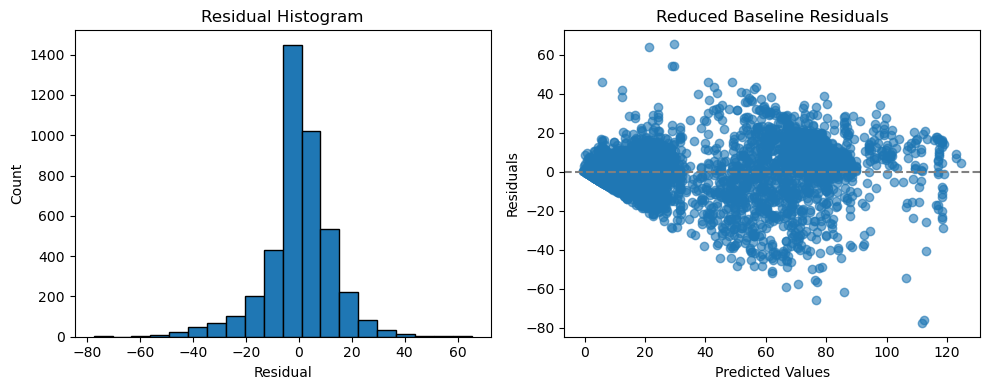

In [21]:
pipeline_reduced = Pipeline([
    ("scaler", StandardScaler()),
    ("gbr", GradientBoostingRegressor(random_state=42))
])

pipeline_reduced.fit(Xr_train, yr_train)
yr_pred_test = pipeline_reduced.predict(Xr_test)

print("Baseline reduced-feature model performance:")
reduced_baseline_metrics = print_regression_metrics(yr_test, yr_pred_test, prefix="  ")

plot_pred_vs_true(yr_test, yr_pred_test, "Reduced Baseline: Predicted vs True")
plot_residuals(yr_test, yr_pred_test, "Reduced Baseline Residuals")

## Grid Search for Hyperparameters

In [22]:
pipeline_reduced = Pipeline([
    ("scaler", StandardScaler()),
    ("gbr", GradientBoostingRegressor(random_state=42))
])

gs_reduced = GridSearchCV(
    estimator=pipeline_reduced,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

gs_reduced.fit(Xr_train, yr_train)

print("Best parameters for reduced model:")
print(gs_reduced.best_params_)
print("Best CV score (neg RMSE):", gs_reduced.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END gbr__learning_rate=0.01, gbr__max_depth=3, gbr__min_samples_split=2, gbr__n_estimators=100, gbr__subsample=0.8; total time=   4.0s
[CV] END gbr__learning_rate=0.01, gbr__max_depth=3, gbr__min_samples_split=2, gbr__n_estimators=100, gbr__subsample=0.8; total time=   4.0s
[CV] END gbr__learning_rate=0.01, gbr__max_depth=3, gbr__min_samples_split=2, gbr__n_estimators=100, gbr__subsample=0.8; total time=   4.0s
[CV] END gbr__learning_rate=0.01, gbr__max_depth=3, gbr__min_samples_split=2, gbr__n_estimators=100, gbr__subsample=0.8; total time=   4.1s
[CV] END gbr__learning_rate=0.01, gbr__max_depth=3, gbr__min_samples_split=2, gbr__n_estimators=100, gbr__subsample=0.8; total time=   4.1s
[CV] END gbr__learning_rate=0.01, gbr__max_depth=3, gbr__min_samples_split=2, gbr__n_estimators=100, gbr__subsample=1.0; total time=   4.8s
[CV] END gbr__learning_rate=0.01, gbr__max_depth=3, gbr__min_samples_split=2, gbr__n_estimators=10

In [23]:
pd.DataFrame(gs_reduced.cv_results_).sort_values("rank_test_score").head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gbr__learning_rate,param_gbr__max_depth,param_gbr__min_samples_split,param_gbr__n_estimators,param_gbr__subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
71,30.245884,2.297163,0.017945,0.000766,0.10,7,5,300,1.0,"{'gbr__learning_rate': 0.1, 'gbr__max_depth': ...",-10.875246,-9.940100,-9.805377,-10.025750,-10.194836,-10.168262,0.375389,1,-5.320416,-5.425981,-5.480467,-5.330087,-5.264007,-5.364192,0.078044
67,34.025895,0.107740,0.022861,0.002586,0.10,7,2,300,1.0,"{'gbr__learning_rate': 0.1, 'gbr__max_depth': ...",-10.881840,-9.896165,-9.786443,-10.164758,-10.222479,-10.190337,0.381977,2,-5.236000,-5.353045,-5.447588,-5.263595,-5.240861,-5.308218,0.081458
42,27.020924,0.105692,0.027678,0.002123,0.05,7,2,300,0.8,"{'gbr__learning_rate': 0.05, 'gbr__max_depth':...",-10.813485,-9.977277,-9.972109,-10.054804,-10.273770,-10.218289,0.317098,3,-6.151152,-6.478168,-6.496393,-6.172614,-6.415112,-6.342688,0.150224
70,27.470726,0.104874,0.025157,0.003139,0.10,7,5,300,0.8,"{'gbr__learning_rate': 0.1, 'gbr__max_depth': ...",-10.903371,-10.050032,-9.933767,-10.020059,-10.213845,-10.224215,0.351494,4,-5.104945,-5.476533,-5.546109,-5.153196,-5.425552,-5.341267,0.178090
66,27.570822,0.107428,0.025278,0.001299,0.10,7,2,300,0.8,"{'gbr__learning_rate': 0.1, 'gbr__max_depth': ...",-11.020570,-9.956137,-9.654546,-10.192701,-10.300175,-10.224826,0.455485,5,-5.085882,-5.522240,-5.540020,-5.139725,-5.394265,-5.336427,0.190151
46,27.208970,0.180381,0.028230,0.000755,0.05,7,5,300,0.8,"{'gbr__learning_rate': 0.05, 'gbr__max_depth':...",-10.908676,-10.030843,-9.907875,-10.092046,-10.302015,-10.248291,0.353998,6,-6.249588,-6.528299,-6.514043,-6.240393,-6.501783,-6.406821,0.132432
43,33.232321,0.117055,0.026545,0.002104,0.05,7,2,300,1.0,"{'gbr__learning_rate': 0.05, 'gbr__max_depth':...",-10.951875,-10.021114,-9.900578,-10.106979,-10.382837,-10.272677,0.374871,7,-6.374797,-6.478130,-6.500463,-6.325760,-6.411063,-6.418042,0.064558
47,33.373075,0.245184,0.028596,0.001460,0.05,7,5,300,1.0,"{'gbr__learning_rate': 0.05, 'gbr__max_depth':...",-10.963840,-10.093787,-9.966484,-10.075815,-10.392104,-10.298406,0.361433,8,-6.437283,-6.599873,-6.648160,-6.372833,-6.449822,-6.501594,0.104437
65,11.082317,0.043569,0.011107,0.001280,0.10,7,2,100,1.0,"{'gbr__learning_rate': 0.1, 'gbr__max_depth': ...",-11.070170,-10.277650,-10.047621,-10.405511,-10.567079,-10.473606,0.343256,9,-6.950626,-7.148082,-7.120579,-7.014388,-7.153830,-7.077501,0.080925
69,11.076214,0.049945,0.011105,0.001314,0.10,7,5,100,1.0,"{'gbr__learning_rate': 0.1, 'gbr__max_depth': ...",-11.091825,-10.335506,-10.172233,-10.301152,-10.496016,-10.479347,0.323163,10,-7.044305,-7.304177,-7.275880,-7.071657,-7.166726,-7.172549,0.104559


## Evaluate model

Test performance for best reduced-feature model:
  MAE:  5.7048
  RMSE: 9.5360
  R²:   0.9210


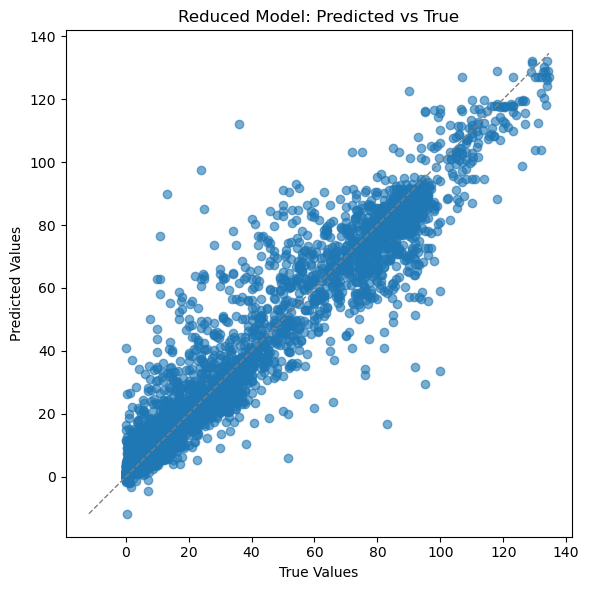

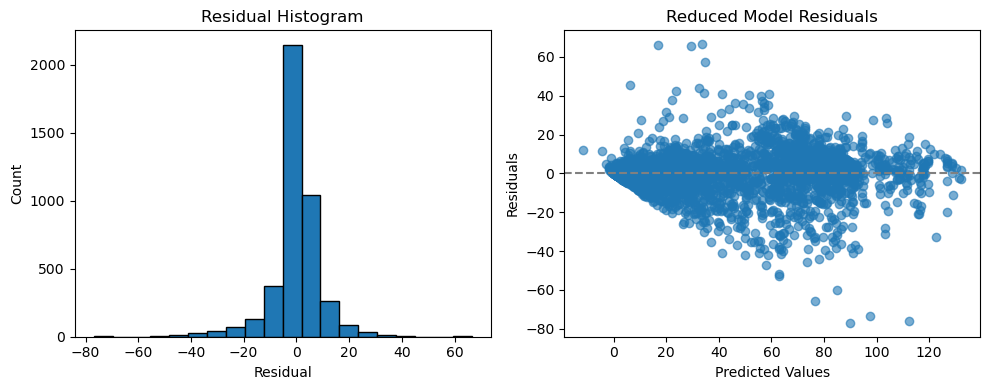

In [24]:
best_reduced_model = gs_reduced.best_estimator_
yr_pred_best = best_reduced_model.predict(Xr_test)

print("Test performance for best reduced-feature model:")
reduced_metrics = print_regression_metrics(yr_test, yr_pred_best, prefix="  ")

plot_pred_vs_true(yr_test, yr_pred_best, "Reduced Model: Predicted vs True")
plot_residuals(yr_test, yr_pred_best, "Reduced Model Residuals")

## Feature Importance

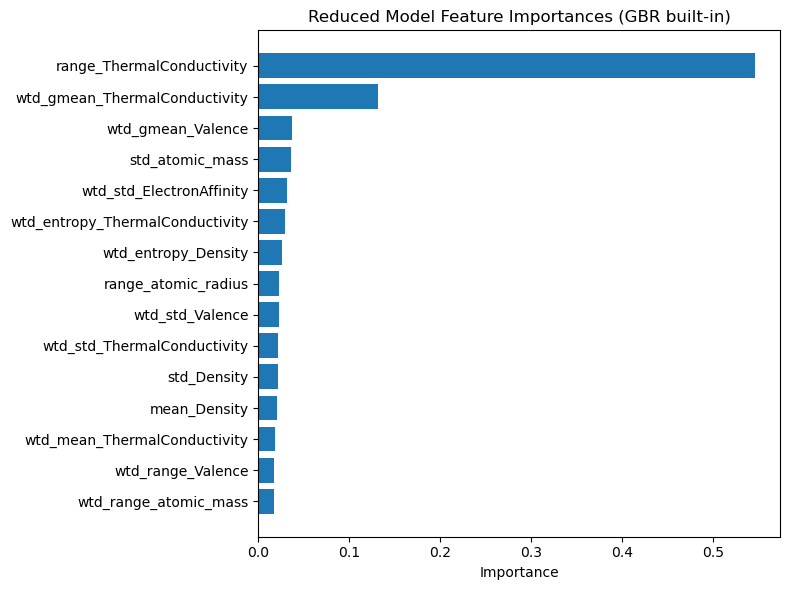

,feature,importance
0,range_ThermalConductivity,0.546309
2,wtd_gmean_ThermalConductivity,0.131186
5,wtd_gmean_Valence,0.037624
4,std_atomic_mass,0.035889
3,wtd_std_ElectronAffinity,0.031315
6,wtd_entropy_ThermalConductivity,0.029092
13,wtd_entropy_Density,0.025823
1,range_atomic_radius,0.023004
12,wtd_std_Valence,0.022331
8,wtd_std_ThermalConductivity,0.022029


In [25]:
reduced_importances = best_reduced_model.named_steps["gbr"].feature_importances_
reduced_names = X_reduced.columns

sorted_idx = np.argsort(reduced_importances)[::-1]

plt.figure(figsize=(8,6))
plt.barh(reduced_names[sorted_idx], reduced_importances[sorted_idx])
plt.gca().invert_yaxis()
plt.title("Reduced Model Feature Importances (GBR built-in)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": reduced_names,
    "importance": reduced_importances
}).sort_values("importance", ascending=False)

## Permutation Importance

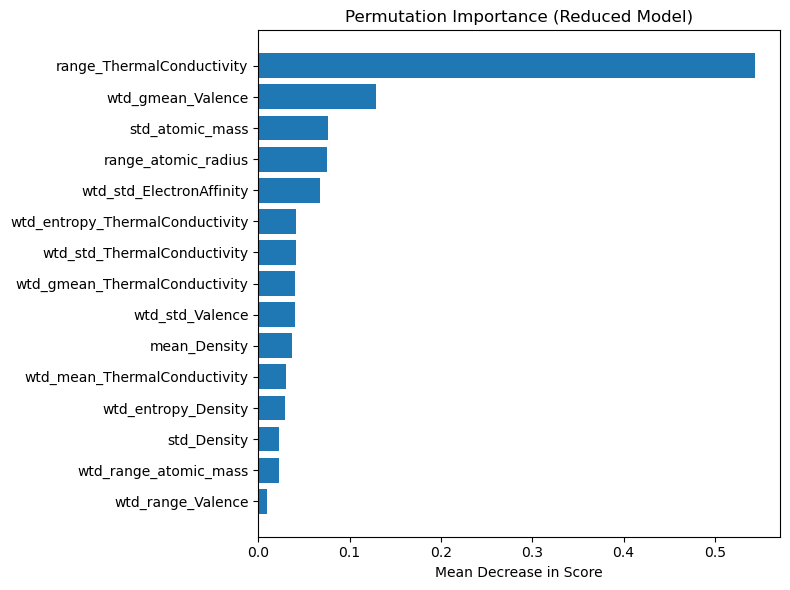

,feature,importance_mean,importance_std
0,range_ThermalConductivity,0.544165,0.012779
5,wtd_gmean_Valence,0.129431,0.004396
4,std_atomic_mass,0.075917,0.003627
1,range_atomic_radius,0.075663,0.002801
3,wtd_std_ElectronAffinity,0.067645,0.002339
6,wtd_entropy_ThermalConductivity,0.041217,0.002304
8,wtd_std_ThermalConductivity,0.041152,0.001766
2,wtd_gmean_ThermalConductivity,0.040394,0.002205
12,wtd_std_Valence,0.039859,0.002038
9,mean_Density,0.036622,0.002147


In [26]:
perm_reduced = permutation_importance(
    best_reduced_model, Xr_test, yr_test,
    n_repeats=30, random_state=42, n_jobs=-1
)

perm_reduced_df = pd.DataFrame({
    "feature": X_reduced.columns,
    "importance_mean": perm_reduced.importances_mean,
    "importance_std": perm_reduced.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(perm_reduced_df["feature"], perm_reduced_df["importance_mean"])
plt.gca().invert_yaxis()
plt.title("Permutation Importance (Reduced Model)")
plt.xlabel("Mean Decrease in Score")
plt.tight_layout()
plt.show()

perm_reduced_df